# Week 1: Exoplanet Detection Project
## Dataset Exploration & Visualization

**Author:** Mann  
**Date:** March 2026  
**Dataset:** Kepler Labelled Time Series Data  
**Goal:** Load dataset, understand structure, visualize light curves
**Note:** This notebook corresponds to the initial exploration phase of the project.

## 1. Import Libraries
This section imports all libraries used throughout the project, including:
- NumPy and Pandas for data handling
- Matplotlib and Plotly for visualization
- TensorFlow for deep learning
- Lightkurve for Kepler light curve processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Kepler Dataset

The Kepler labelled dataset is loaded into Pandas DataFrames.
Each row represents a stellar light curve, while columns contain flux measurements across time.

In [2]:
train = pd.read_csv("../data/raw/exoTrain.csv")
test = pd.read_csv("../data/raw/exoTest.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (5087, 3198)
Test shape : (570, 3198)


## 3. Explore Dataset Structure

This section examines the overall structure of the Kepler dataset,
including class distribution, feature dimensions, column organization,
and missing-value analysis.

Understanding the dataset structure is important before applying
preprocessing or machine learning techniques.

In [3]:
print("First 5 rows:")
train.tail()

#Understand the labels
print("Label counts in Training data:")
print(train["LABEL"].value_counts())
print("\nLabel counts in Test data:")
print(test["LABEL"].value_counts())

#Understand the columns
print("Total columns:", train.shape[1])
print("\nFirst 10 column names:")
print(train.columns[:10].tolist())
print("\nLast 5 column names:")
print(train.columns[-5:].tolist())

#Check for missing values
print("Missing values in Training data:")
print(train.isnull().sum().sum())
print("\nMissing values in Test data:")
print(test.isnull().sum().sum())

First 5 rows:
Label counts in Training data:
LABEL
1    5050
2      37
Name: count, dtype: int64

Label counts in Test data:
LABEL
1    565
2      5
Name: count, dtype: int64
Total columns: 3198

First 10 column names:
['LABEL', 'FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6', 'FLUX.7', 'FLUX.8', 'FLUX.9']

Last 5 column names:
['FLUX.3193', 'FLUX.3194', 'FLUX.3195', 'FLUX.3196', 'FLUX.3197']
Missing values in Training data:
0

Missing values in Test data:
0


## 4. Visualize Stellar Light Curves

This section compares the light curves of:
- a confirmed exoplanet host star
- a non-exoplanet star

The goal is to visually understand the key transit signature:
periodic dips in stellar brightness caused by a planet passing
in front of its host star.

Exoplanet stars typically show repeating transit patterns,
while non-planet stars contain random fluctuations and noise.

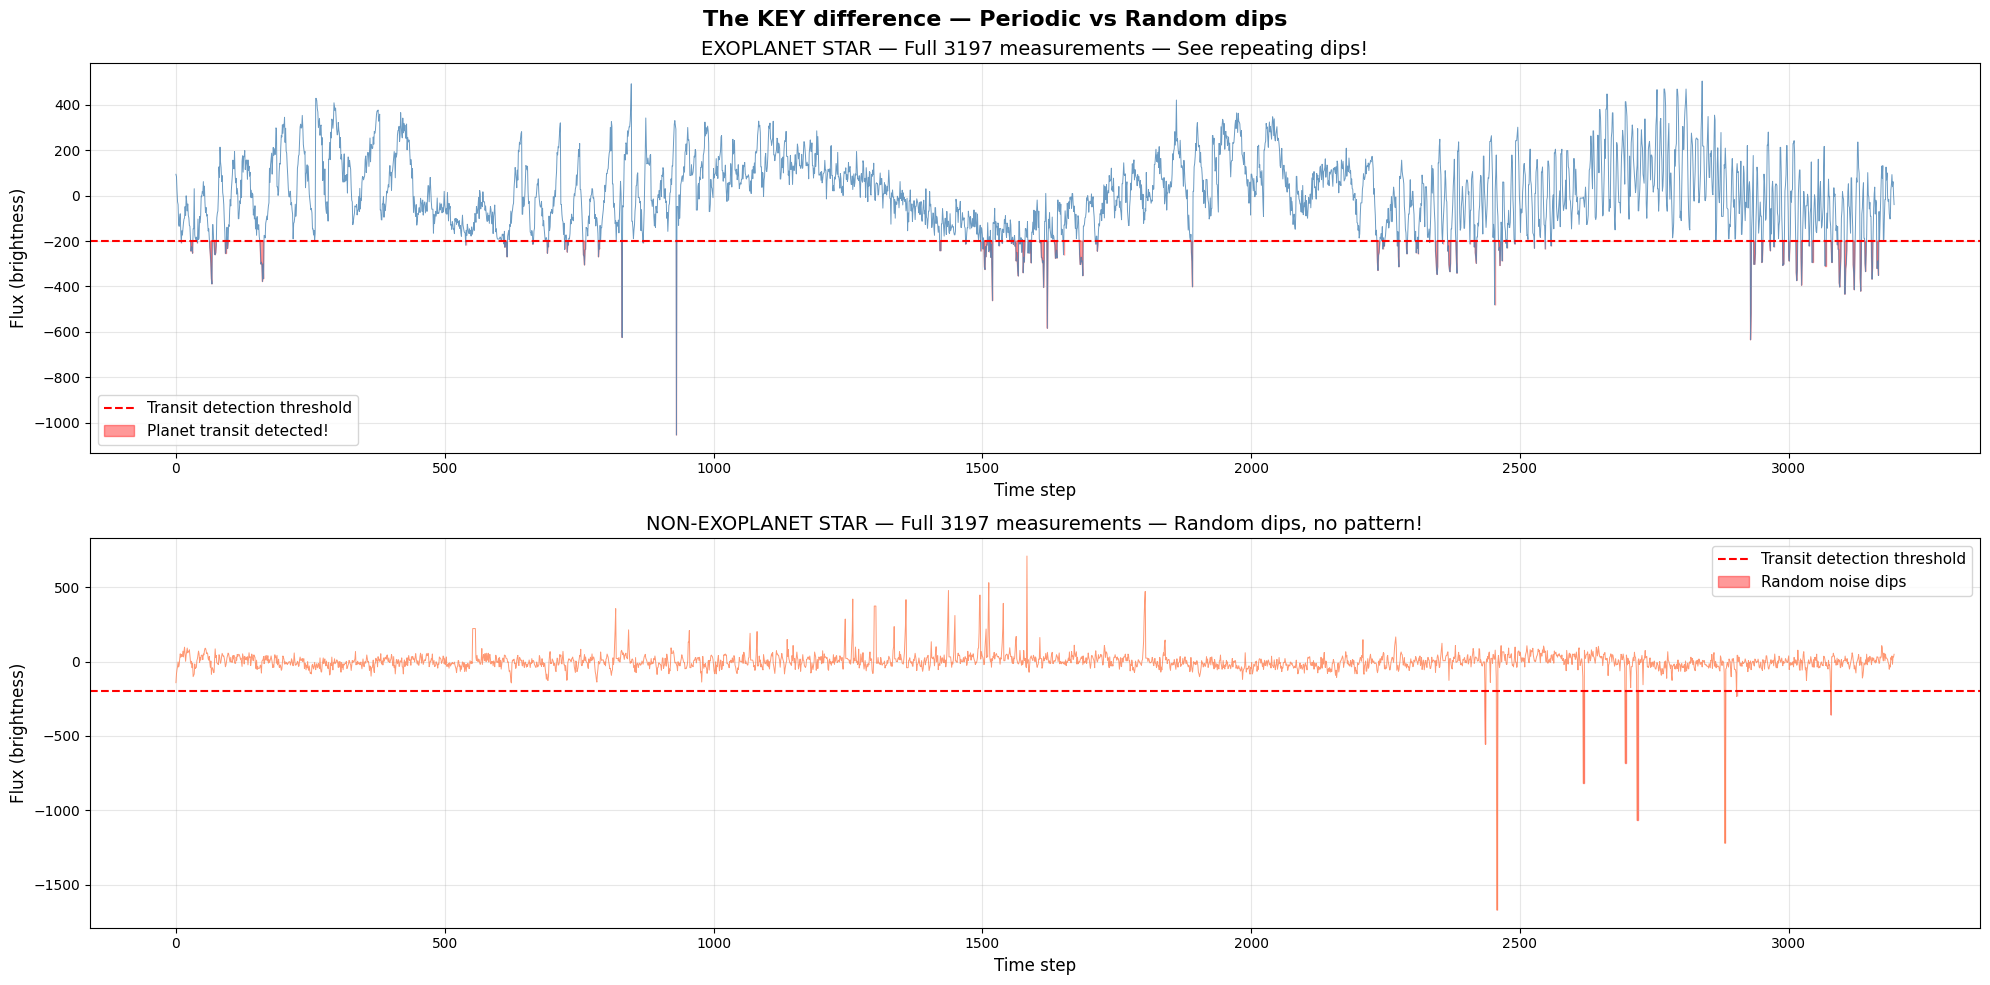

In [4]:
# See the full periodic pattern clearly

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# Full exoplanet light curve
planet_star = train[train["LABEL"] == 2].iloc[0]
flux_planet = planet_star.drop("LABEL").values
time = range(len(flux_planet))

axes[0].plot(time, flux_planet, linewidth=0.7, color="steelblue", alpha=0.8)
axes[0].axhline(y=-200, color="red", linewidth=1.5, 
                linestyle="--", label="Transit detection threshold")
axes[0].fill_between(time, flux_planet, -200,
                     where=(flux_planet < -200),
                     color="red", alpha=0.4, label="Planet transit detected!")
axes[0].set_title("EXOPLANET STAR — Full 3197 measurements — See repeating dips!", 
                  fontsize=14)
axes[0].set_ylabel("Flux (brightness)", fontsize=12)
axes[0].set_xlabel("Time step", fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Full non-exoplanet light curve
no_planet_star = train[train["LABEL"] == 1].iloc[0]
flux_no_planet = no_planet_star.drop("LABEL").values

axes[1].plot(time, flux_no_planet, linewidth=0.7, color="coral", alpha=0.8)
axes[1].axhline(y=-200, color="red", linewidth=1.5,
                linestyle="--", label="Transit detection threshold")
axes[1].fill_between(time, flux_no_planet, -200,
                     where=(flux_no_planet < -200),
                     color="red", alpha=0.4, label="Random noise dips")
axes[1].set_title("NON-EXOPLANET STAR — Full 3197 measurements — Random dips, no pattern!", 
                  fontsize=14)
axes[1].set_ylabel("Flux (brightness)", fontsize=12)
axes[1].set_xlabel("Time step", fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle("The KEY difference — Periodic vs Random dips", 
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/periodic_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary — Key Findings

- Dataset contains 5,087 stellar light curves
  - 5,050 non-planet stars
  - 37 confirmed exoplanet stars

- Each light curve contains 3,197 flux measurements
- No missing values were found in train or test datasets
- Confirmed exoplanets show periodic transit dips in stellar brightness
- Transit events are subtle and often buried in noise
- Severe class imbalance (~0.7% positive class) is a major machine learning challenge
- Dataset exploration established the foundation for preprocessing and CNN model development